In [3]:
import numpy as np
from urllib import request
import gzip
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

def load():
    with open("data.pkl",'rb') as f:
        mnist = pickle.load(f)
    return mnist["training_images"], mnist["training_labels"], mnist["test_images"], mnist["test_labels"]


In [4]:

train_images, train_labels, test_images, test_labels = load()


In [5]:
train_images = train_images.reshape(-1, 28, 28)#[:5000]
test_images = test_images.reshape(-1, 28, 28)#[:2000]

In [6]:
train_labels = train_labels#[:5000]
test_labels = test_labels#[:2000]

In [7]:
from PIL import Image
Image.fromarray(train_images[0].astype(np.uint8))

Label: 5


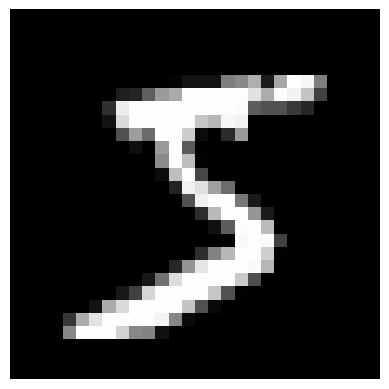

In [8]:
def print_train_image(idx):
    img = train_images[idx]
    label = train_labels[idx]
    print(f"Label: {label}")
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

idx = 0  # Change this to see other images
print_train_image(idx)

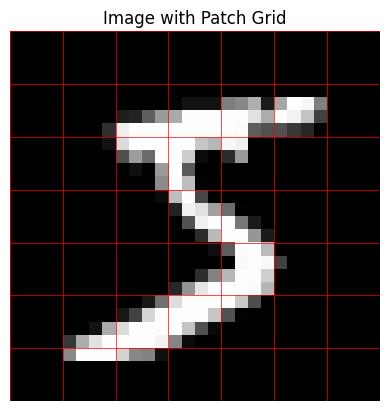

In [9]:
idx = 0
img = train_images[idx]
plt.imshow(img, cmap='gray')
d = 4  # patch size
for i in range(0, img.shape[0], d):
    plt.axhline(i-0.5, color='red', linewidth=0.5)
for j in range(0, img.shape[1], d):
    plt.axvline(j-0.5, color='red', linewidth=0.5)
plt.title("Image with Patch Grid")
plt.axis('off')
plt.show()

In [10]:

### Ex1
def binary2decimal(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

def f_ex1(image, d=3):
    h,w = image.shape
    size_left_right = (d-1)//2
    size_up_down = (d-1)//2
    padded_image = np.pad(image, ((size_up_down, size_up_down), (size_left_right, size_left_right)),
                          constant_values=-1)
    results = []
    for i in range(size_up_down, h):
        for j in range(size_left_right, w):
            output_representation = np.zeros((d*d)-1)
            patch = padded_image[i-size_left_right:i+size_left_right+1,
                          j-size_up_down:j+size_up_down+1]
            value = padded_image[i][j]
            comparison = (patch>value)*1
            result = comparison.reshape(-1)

            output_representation[:len(output_representation)//2] = result[:len(output_representation)//2]
            output_representation[len(output_representation)//2:] = result[len(output_representation)//2 + 1:]
            results.append(output_representation)
 
    histogram = np.zeros((2**(d*d-1)))
    for result in results:
        position = binary2decimal(result)
        histogram[int(position)]+=1
    return histogram

def process_data(images):
    results = []
    for image in tqdm(images):
        hist = f_ex1(image)
        results.append(hist)
    return np.array(results)

train_hist = process_data(train_images)

100%|██████████| 5000/5000 [00:53<00:00, 93.09it/s] 


Label: 5


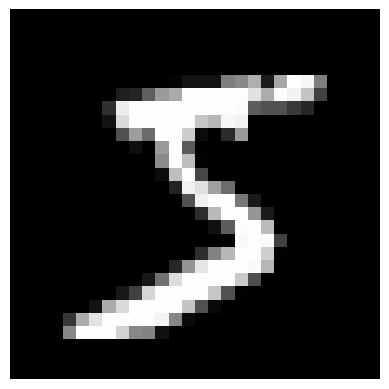

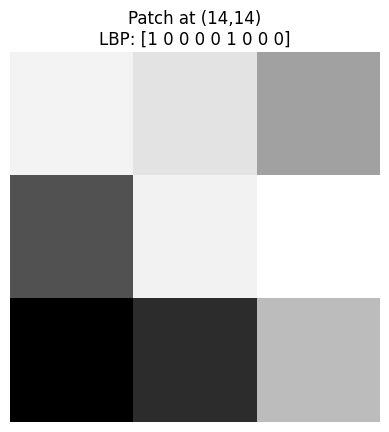

In [11]:
# Print the original image and its histogram
idx = 0
print_train_image(idx)

# Show a patch and its LBP binary pattern
d = 3
i, j = 14, 14  # Center of the image
patch = train_images[idx][i-1:i+2, j-1:j+2]
center = patch[1, 1]
lbp = (patch > center).astype(int)
plt.imshow(patch, cmap='gray')
plt.title(f"Patch at ({i},{j})\nLBP: {lbp.flatten()}")
plt.axis('off')
plt.show()

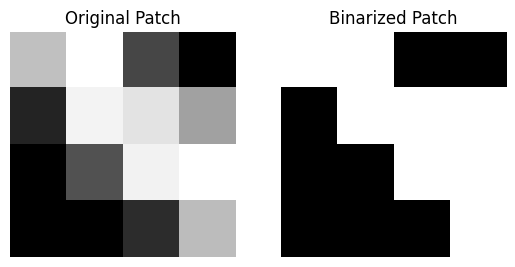

In [12]:
idx = 0
img = train_images[idx]
d = 4  # Patch size

patch = img[3*d:4*d, 3*d:4*d]
plt.subplot(1,2,1)
plt.imshow(patch, cmap='gray')
plt.title("Original Patch")
plt.axis('off')

binary_patch = (patch >= patch.mean()).astype(int)
plt.subplot(1,2,2)
plt.imshow(binary_patch, cmap='gray')
plt.title("Binarized Patch")
plt.axis('off')
plt.show()

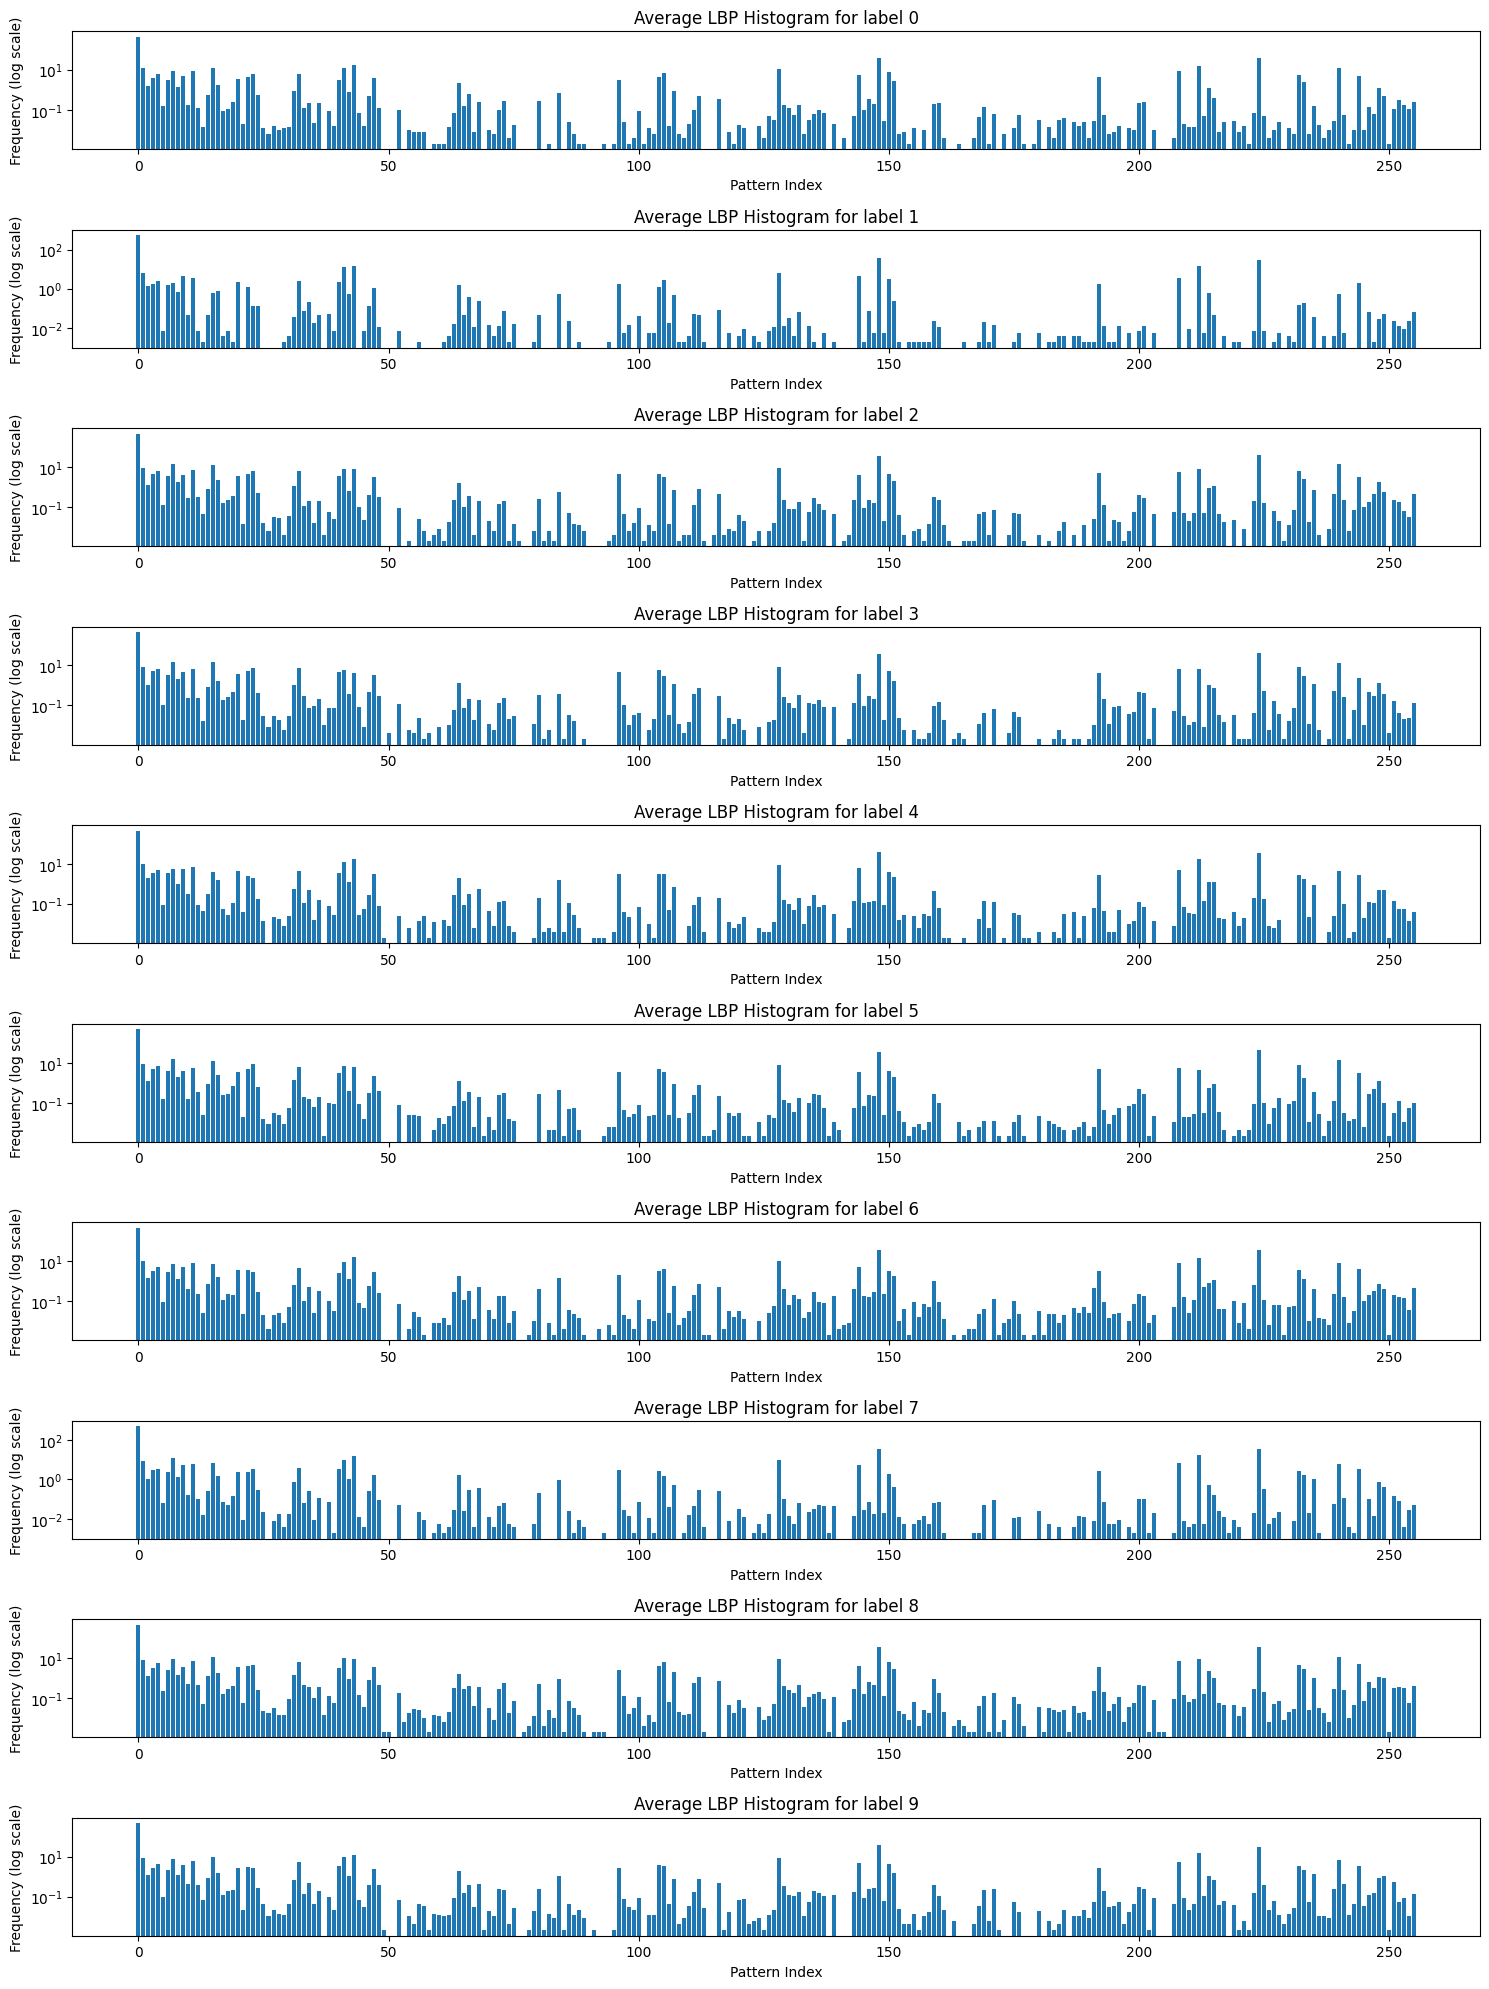

In [13]:
num_classes = len(np.unique(train_labels))
plt.figure(figsize=(15, 2 * num_classes))

for label in range(num_classes):
    idxs = np.where(train_labels == label)[0]
    avg_hist = train_hist[idxs].mean(axis=0)
    plt.subplot(num_classes, 1, label + 1)
    plt.bar(np.arange(len(avg_hist)), avg_hist)
    plt.yscale('log')  # <-- Use logarithmic scale for y-axis
    plt.title(f"Average LBP Histogram for label {label}")
    plt.xlabel("Pattern Index")
    plt.ylabel("Frequency (log scale)")
    plt.tight_layout()

plt.show()

In [14]:
train_hist[0]

array([448.,   9.,   0.,   7.,   5.,   0.,   3.,  15.,   0.,   4.,   0.,
         3.,   0.,   0.,   0.,  31.,   1.,   0.,   0.,   0.,   6.,   0.,
         4.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   9.,
         0.,   0.,   1.,   0.,   0.,   0.,   0.,   4.,   0.,   0.,   0.,
         0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.,   0.,   0.,
         0.,   0.,   0.,   0.,   1.,   9.,   5.,   0.,   1.,   0.,   0.,
         0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,  10.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   3.,   0.,   1.,   1.,  28.,   0.,   

In [15]:
test_hist = process_data(test_images)

100%|██████████| 2000/2000 [00:21<00:00, 92.70it/s]


In [16]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
clf = SVC()
scaler = StandardScaler()
scaler.fit(train_hist)
train_hist_scaled = scaler.transform(train_hist)
test_hist_scaled = scaler.transform(test_hist)
clf.fit(train_hist_scaled, train_labels)

SVC()

In [17]:
clf.score(test_hist_scaled, test_labels)

0.7435

In [18]:
train_hist[0].shape

(256,)

In [19]:
### Ex2
import cv2
def compute_gradient_magnitude(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(np.square(sobelx) + np.square(sobely))
    return grad_mag
def process_images(images):
    results = []
    for image in tqdm(images):
        results.append(compute_gradient_magnitude(image))
    return np.array(results)

train_grad_mag = process_images(train_images)
        

100%|██████████| 5000/5000 [00:00<00:00, 30729.48it/s]


Label: 5


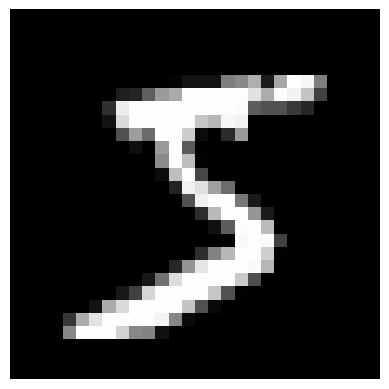

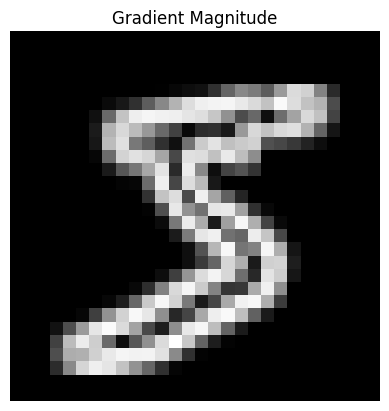

In [20]:
# Show original image and its gradient magnitude
idx = 0
print_train_image(idx)
# Show gradient magnitude
plt.imshow(train_grad_mag[idx], cmap='gray')
plt.title("Gradient Magnitude")
plt.axis('off')
plt.show()

In [21]:
test_grad_mag = process_images(test_images)

100%|██████████| 2000/2000 [00:00<00:00, 32744.59it/s]


In [22]:
def get_top_k_regions(grad_mag, original_image, k=30, d=4):
    patches_mag = grad_mag.reshape(-1, d, d)
    original_image = original_image.reshape(-1, d, d)
    patches_mag = np.mean(patches_mag, axis=(1, 2))
    sorted_indices = np.argsort(patches_mag)
    output = []
    for i in range(original_image.shape[0]):
        if i not in sorted_indices[-k:]:
            continue
        output.append(original_image[i])
    return np.array(output).reshape(-1)

def transform_images(images, grad_mags):
    results = []
    for i, image in enumerate(tqdm(images)):
        results.append(get_top_k_regions(grad_mags[i], image))
    return np.array(results)

ex2_train_data = transform_images(train_images, train_grad_mag)
ex2_test_data = transform_images(test_images, test_grad_mag)

100%|██████████| 2000/2000 [00:00<00:00, 2972.59it/s]


In [23]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
clf = SVC(C=10)

clf.fit(ex2_train_data, train_labels)

SVC(C=10)

In [24]:
clf.score(ex2_test_data, test_labels)

0.8545

In [25]:
# Ex3
def compute_gradient_direction(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    grad_direction = np.arctan2(sobely, sobelx)
    return grad_direction

def process_images(images):
    results = []
    for image in tqdm(images):
        results.append(compute_gradient_direction(image))
    return np.array(results)

train_grad_direction = process_images(train_images)
test_grad_direction = process_images(test_images)
    
def non_max_suppression_gradient(img, direction):
    h, w = img.shape
    output = np.zeros((h,w), dtype=np.int32)
    angle = direction * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1,h-1):
        for j in range(1,w-1):
            neighbour1 = 255
            neighbour2 = 255
                
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                neighbour1 = img[i, j+1]
                neighbour2 = img[i, j-1]
  
            elif (22.5 <= angle[i,j] < 67.5):
                neighbour1 = img[i+1, j-1]
                neighbour2 = img[i-1, j+1]

            elif (67.5 <= angle[i,j] < 112.5):
                neighbour1 = img[i+1, j]
                neighbour2 = img[i-1, j]

            elif (112.5 <= angle[i,j] < 157.5):
                neighbour1 = img[i-1, j-1]
                neighbour2 = img[i+1, j+1]

            if (img[i,j] >= neighbour1) and (img[i,j] >= neighbour2):
                output[i,j] = img[i,j]
            else:
                output[i,j] = 0
    
    return output

def process_image(mags, directions):
    results = []
    for i, mag in enumerate(mags):
        results.append(non_max_suppression_gradient(mag, directions[i]))
        
    return np.array(results)

new_train_mags = process_image(train_grad_mag, train_grad_direction)
new_test_mags = process_image(test_grad_mag, test_grad_direction)

100%|██████████| 2000/2000 [00:00<00:00, 26422.73it/s]


Label: 5


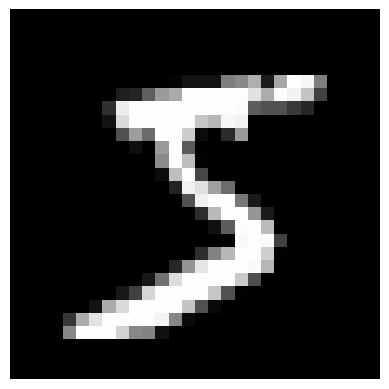

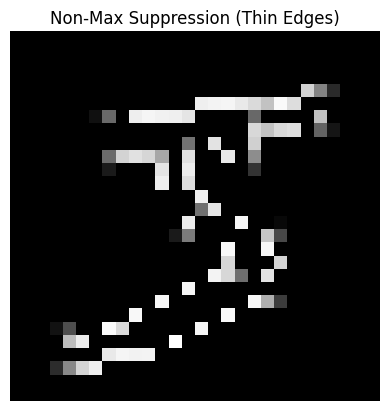

In [26]:
# Show the original image and its non-max suppressed gradient magnitude
idx = 0
print_train_image(idx)

plt.imshow(new_train_mags[idx], cmap='gray')
plt.title("Non-Max Suppression (Thin Edges)")
plt.axis('off')
plt.show()

Label: 5


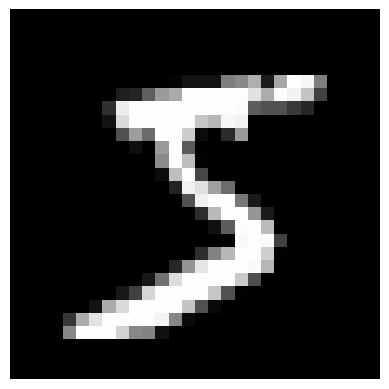

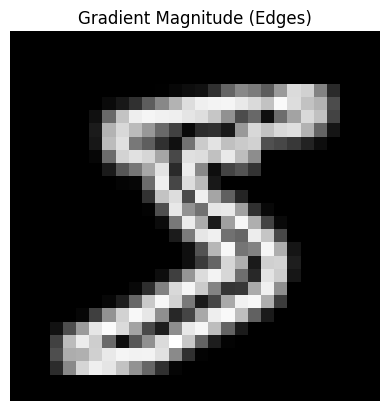

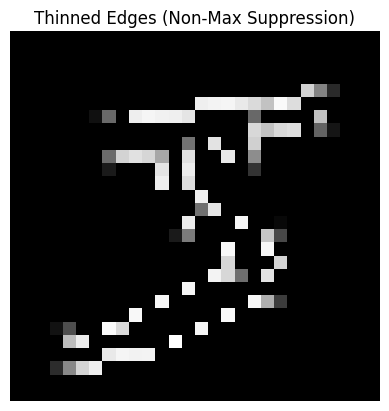

In [27]:
idx = 0
print_train_image(idx)

plt.imshow(train_grad_mag[idx], cmap='gray')
plt.title("Gradient Magnitude (Edges)")
plt.axis('off')
plt.show()

plt.imshow(new_train_mags[idx], cmap='gray')
plt.title("Thinned Edges (Non-Max Suppression)")
plt.axis('off')
plt.show()

In [28]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
clf = SVC(C=10)

clf.fit(new_train_mags.reshape(-1,784), train_labels)

SVC(C=10)

In [29]:
clf.score(new_test_mags.reshape(-1,784), test_labels)

0.8505

In [30]:
## Ex 4
def binarize_image(image, d=4):
    patches = image.reshape(-1, d, d)
    outputs = []
    for patch in patches:
        if d%2==0:
            output_representation = np.zeros((d*d))
            value = np.mean(patch[d//2-1: d//2+1,d//2-1: d//2+1])
        else:
            output_representation = np.zeros((d*d)-1)
            value = patch[d//2, d//2]
        comparison = (patch>=value)*1
        result = comparison.reshape(-1)
        if d%2==0:
            output_representation= result
        else:
            output_representation[:len(output_representation)//2] = result[:len(output_representation)//2]
            output_representation[len(output_representation)//2:] = result[len(output_representation)//2 + 1:]
        outputs.append(output_representation)
    return np.concatenate(outputs)
def process_data(images):
    results = []
    for image in tqdm(images):
        results.append(binarize_image(image))
    return np.array(results)
train_binary_data = process_data(train_images)
test_binary_data = process_data(test_images)
    

100%|██████████| 2000/2000 [00:01<00:00, 1101.17it/s]


Label: 5


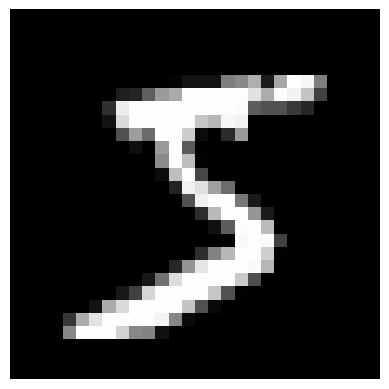

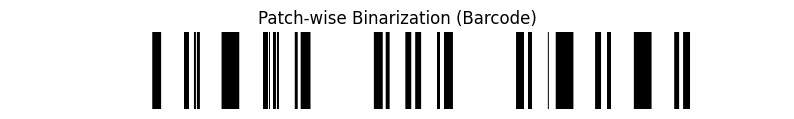

In [31]:
# Show the original image and its patch binary representation
idx = 0
print_train_image(idx)

binary_vec = train_binary_data[idx]
plt.figure(figsize=(10,1))
plt.imshow(binary_vec.reshape(1, -1), cmap='gray', aspect='auto')
plt.title("Patch-wise Binarization (Barcode)")
plt.axis('off')
plt.show()

In [32]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=7)
neigh.fit(train_binary_data, train_labels)
neigh.score(test_binary_data, test_labels)

0.86

In [33]:
## Ex5
def intersection_kernel(hist1, hist2):
    hist1 = np.expand_dims(hist1, axis=0)
    hist2 = np.expand_dims(hist2, axis=0)
    concatenation = np.concatenate((hist1,hist2),axis=0)
    minimum = np.min(concatenation,axis=0)
    return np.sum(minimum)

def compute_kernel_matrix(histograms1, histograms2, train=True):
    kernel_matrix = np.zeros((len(histograms1), len(histograms2)))
    if train:
        for i in tqdm(range(len(histograms1))):
            for j in range(i, len(histograms2)):
                kernel_matrix[i][j] = intersection_kernel(histograms1[i], histograms2[j])
                kernel_matrix[j][i] = kernel_matrix[i][j]
    else:
        for i in tqdm(range(len(histograms1))):
            for j in range(len(histograms2)):
                kernel_matrix[i][j] = intersection_kernel(histograms1[i], histograms2[j])
    return kernel_matrix
                   
train_matrix = compute_kernel_matrix(train_hist_scaled, train_hist_scaled)
test_matrix = compute_kernel_matrix(train_hist_scaled, test_hist_scaled, train=False)

100%|██████████| 5000/5000 [03:26<00:00, 24.18it/s]


In [34]:
train_matrix.shape, test_matrix.shape

((5000, 5000), (5000, 2000))

In [35]:
train_hist_scaled.shape

(5000, 256)

In [36]:
clf = SVC(kernel='precomputed')

clf.fit(train_matrix, train_labels)
clf.score(test_matrix.T, test_labels)

0.771